In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

0. CONFIGURATION

In [ ]:
DATA_DIR = Path(r"")

POSTINGS_FILE = DATA_DIR / "linkedin_job_postings.csv"
SKILLS_FILE = DATA_DIR / "job_skills.csv"
SUMMARY_FILE = DATA_DIR / "job_summary.csv"

OUTPUT_DIR = DATA_DIR / "eda_output"
OUTPUT_DIR.mkdir(exist_ok=True)

1. LOAD DATA

In [ ]:
print("1. LOADING DATA")

postings = pd.read_csv(POSTINGS_FILE)
skills = pd.read_csv(SKILLS_FILE)
summary = pd.read_csv(SUMMARY_FILE)

print("\nPostings shape:", postings.shape)
print("Skills shape:", skills.shape)
print("Summary shape:", summary.shape)

print("\nPostings columns:")
print(postings.columns.tolist())

print("\nSkills columns:")
print(skills.columns.tolist())

print("\nSummary columns:")
print(summary.columns.tolist())

1. LOADING DATA

Postings shape: (1348454, 14)
Skills shape: (1296381, 2)
Summary shape: (1297332, 2)

Postings columns:
['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']

Skills columns:
['job_link', 'job_skills']

Summary columns:
['job_link', 'job_summary']


2. BASIC DATASET PROFILING

In [ ]:
def profile_dataset(df, name):
    print(f"DATASET PROFILE: {name}")

    print("Rows:", len(df))
    print("Columns:", len(df.columns))

    print("\nMissing values:")
    missing = df.isna().sum()
    missing_pct = (df.isna().mean() * 100).round(2)

    missing_table = pd.DataFrame({
        "missing_count": missing,
        "missing_pct": missing_pct
    })

    print(missing_table[missing_table["missing_count"] > 0])

    print("\nDuplicate rows:", df.duplicated().sum())

    if "job_link" in df.columns:
        print("Duplicate job_link:", df["job_link"].duplicated().sum())
        print("Unique job_link:", df["job_link"].nunique())

    return missing_table


postings_missing = profile_dataset(postings, "linkedin_job_postings")
skills_missing = profile_dataset(skills, "job_skills")
summary_missing = profile_dataset(summary, "job_summary")

# Save profiling information
postings_missing.to_csv(
    OUTPUT_DIR / "postings_missing.csv"
)
skills_missing.to_csv(
    OUTPUT_DIR / "skills_missing.csv"
)
summary_missing.to_csv(
    OUTPUT_DIR / "summary_missing.csv"
)

DATASET PROFILE: linkedin_job_postings
Rows: 1348454
Columns: 14

Missing values:
              missing_count  missing_pct
company                  11          0.0
job_location             19          0.0

Duplicate rows: 0
Duplicate job_link: 0
Unique job_link: 1348454
DATASET PROFILE: job_skills
Rows: 1296381
Columns: 2

Missing values:
            missing_count  missing_pct
job_skills           2085         0.16

Duplicate rows: 0
Duplicate job_link: 0
Unique job_link: 1296381
DATASET PROFILE: job_summary
Rows: 1297332
Columns: 2

Missing values:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Duplicate rows: 0
Duplicate job_link: 0
Unique job_link: 1297332


3. CHECK JOB_LINK INTEGRITY

In [ ]:
print("2. JOB_LINK INTEGRITY")

post_links = set(postings["job_link"].dropna())
skill_links = set(skills["job_link"].dropna())
summary_links = set(summary["job_link"].dropna())

print("Unique posting links:", len(post_links))
print("Unique skill links:", len(skill_links))
print("Unique summary links:", len(summary_links))

print("\nPostings with skills:",
      len(post_links & skill_links))

print("Postings with summary:",
      len(post_links & summary_links))

print("Postings with BOTH:",
      len(post_links & skill_links & summary_links))

print("Postings missing skills:",
      len(post_links - skill_links))

print("Postings missing summary:",
      len(post_links - summary_links))

2. JOB_LINK INTEGRITY
Unique posting links: 1348454
Unique skill links: 1296381
Unique summary links: 1297332

Postings with skills: 1296381
Postings with summary: 1297332
Postings with BOTH: 1296381
Postings missing skills: 52073
Postings missing summary: 51122


4. CHECK DUPLICATES BY JOB_LINK

In [ ]:
print("3. JOB_LINK DUPLICATES")

for name, df in [
    ("Postings", postings),
    ("Skills", skills),
    ("Summary", summary)
]:
    if "job_link" in df.columns:
        duplicated_links = df[
            df["job_link"].duplicated(keep=False)
        ]

        print(f"\n{name}:")
        print("Rows involved in duplicate job_links:",
              len(duplicated_links))

        if len(duplicated_links) > 0:
            print(
                duplicated_links["job_link"]
                .value_counts()
                .head(10)
            )

3. JOB_LINK DUPLICATES

Postings:
Rows involved in duplicate job_links: 0

Skills:
Rows involved in duplicate job_links: 0

Summary:
Rows involved in duplicate job_links: 0


5. MERGE DATASETS

In [ ]:
print("4. MERGING DATASETS")

# Select useful columns only
posting_cols = [
    "job_link",
    "job_title",
    "company",
    "job_location",
    "first_seen"
]

posting_cols = [
    col for col in posting_cols
    if col in postings.columns
]

postings_base = postings[posting_cols].copy()

# Avoid accidental many-to-many merge if duplicate job_links exist
postings_base = postings_base.drop_duplicates(
    subset=["job_link"]
)

skills_base = skills[
    [col for col in ["job_link", "job_skills"]
     if col in skills.columns]
].copy()

skills_base = skills_base.drop_duplicates(
    subset=["job_link"]
)

summary_base = summary.copy()

summary_base = summary_base.drop_duplicates(
    subset=["job_link"]
)

# Merge
merged = postings_base.merge(
    skills_base,
    on="job_link",
    how="left"
)

merged = merged.merge(
    summary_base,
    on="job_link",
    how="left",
    suffixes=("", "_summary")
)

print("Merged shape:", merged.shape)

print("\nMerged missing values:")
print(
    merged.isna().mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

merged.to_csv(
    OUTPUT_DIR / "merged_dataset.csv",
    index=False
)

4. MERGING DATASETS
Merged shape: (1348454, 7)

Merged missing values:
job_skills      4.02
job_summary     3.79
job_link        0.00
job_title       0.00
company         0.00
job_location    0.00
first_seen      0.00
dtype: float64


6. JOB TITLE INSPECTION

In [ ]:
print("5. JOB TITLE EXPLORATION")

merged["job_title_clean"] = (
    merged["job_title"]
    .fillna("")
    .astype(str)
    .str.strip()
)

merged["job_title_lower"] = (
    merged["job_title_clean"]
    .str.lower()
)

print("\nTotal unique job titles:",
      merged["job_title_clean"].nunique())

print("\nExample job titles:")
print(
    merged["job_title_clean"]
    .value_counts()
    .head(30)
)

5. JOB TITLE EXPLORATION

Total unique job titles: 584544

Example job titles:
job_title_clean
LEAD SALES ASSOCIATE-FT                                      7325
Shift Manager                                                5818
First Year Tax Professional                                  5356
Assistant Manager                                            5346
Customer Service Representative                              5203
LEAD SALES ASSOCIATE-PT                                      4924
Store Manager                                                4791
CUSTOMER SERVICE REPRESENTATIVE                              4218
Registered Nurse                                             4190
Hourly Supervisor & Training                                 2955
Travel Allied Health Professional - CT Technologist          2933
Host                                                         2871
Account Executive                                            2631
Senior Accountant                              

7. BASELINE BUSINESS ANALYST FILTER

In [ ]:
print("6. BUSINESS ANALYST FILTER")

ba_mask = merged["job_title_lower"].str.contains(
    r"\bbusiness analyst\b",
    regex=True,
    na=False
)

ba_jobs = merged[ba_mask].copy()

print("Total postings:", len(merged))
print("Business Analyst postings:", len(ba_jobs))

if len(merged) > 0:
    print(
        "BA percentage:",
        round(len(ba_jobs) / len(merged) * 100, 2),
        "%"
    )

print("\nBusiness Analyst titles:")
print(
    ba_jobs["job_title_clean"]
    .value_counts()
    .head(50)
)

ba_jobs.to_csv(
    OUTPUT_DIR / "business_analyst_jobs.csv",
    index=False
)

6. BUSINESS ANALYST FILTER
Total postings: 1348454
Business Analyst postings: 4546
BA percentage: 0.34 %

Business Analyst titles:
job_title_clean
Business Analyst                                         1011
Senior Business Analyst                                   211
JDE Business Analyst (Supply Chain)                       163
JD Edwards Business Analyst                               150
IT Business Analyst                                        64
Technical Business Analyst                                 60
Business Analyst II                                        51
Business Analyst III                                       36
Sr. Business Analyst                                       30
Business Analyst I                                         28
Salesforce Business Analyst                                26
Senior Financial Business Analyst - Tax Technology         22
Business Analyst (Bangkok Based, relocation provided)      22
Guidewire Business Analyst - Senior Associate  

8. EXPLORE RELATED ANALYST TITLES

In [ ]:
print("7. RELATED ANALYST TITLE EXPLORATION")

analyst_keywords = [
    "business analyst",
    "business systems analyst",
    "business intelligence analyst",
    "data analyst",
    "financial analyst",
    "systems analyst",
    "marketing analyst",
    "process analyst",
    "operations analyst",
    "technical analyst",
    "product analyst"
]

title_results = []

for keyword in analyst_keywords:

    mask = merged["job_title_lower"].str.contains(
        re.escape(keyword),
        na=False
    )

    count = mask.sum()

    title_results.append({
        "title_pattern": keyword,
        "job_count": count
    })

related_titles = pd.DataFrame(title_results)

related_titles["percentage"] = (
    related_titles["job_count"] /
    len(merged) * 100
).round(2)

print(related_titles)

related_titles.to_csv(
    OUTPUT_DIR / "related_analyst_titles.csv",
    index=False
)

7. RELATED ANALYST TITLE EXPLORATION
                    title_pattern  job_count  percentage
0                business analyst       4576        0.34
1        business systems analyst        735        0.05
2   business intelligence analyst        238        0.02
3                    data analyst       1933        0.14
4               financial analyst       2419        0.18
5                 systems analyst       1535        0.11
6               marketing analyst        121        0.01
7                 process analyst        168        0.01
8              operations analyst        864        0.06
9               technical analyst        109        0.01
10                product analyst        122        0.01


9. POTENTIAL BA SUBTYPES

In [ ]:
print("8. BUSINESS ANALYST SUBTYPES")

ba_subtype_patterns = {
    "Business Analyst": r"\bbusiness analyst\b",
    "Business Systems Analyst": r"\bbusiness systems analyst\b",
    "Business Intelligence Analyst": r"\bbusiness intelligence analyst\b",
    "Senior Business Analyst": r"\bsenior business analyst\b",
    "Junior Business Analyst": r"\bjunior business analyst\b",
    "Lead Business Analyst": r"\blead business analyst\b",
    "Technical Business Analyst": r"\btechnical business analyst\b",
    "IT Business Analyst": r"\bit business analyst\b",
    "Data Business Analyst": r"\bdata business analyst\b",
    "Business Process Analyst": r"\bbusiness process analyst\b"
}

subtype_results = []

for subtype, pattern in ba_subtype_patterns.items():

    mask = merged["job_title_lower"].str.contains(
        pattern,
        regex=True,
        na=False
    )

    subtype_results.append({
        "subtype": subtype,
        "job_count": mask.sum()
    })

subtypes = pd.DataFrame(subtype_results)

subtypes["percentage_of_all_jobs"] = (
    subtypes["job_count"] /
    len(merged) * 100
).round(2)

subtypes["percentage_of_ba_jobs"] = (
    subtypes["job_count"] /
    len(ba_jobs) * 100
).round(2)

print(subtypes)

subtypes.to_csv(
    OUTPUT_DIR / "ba_subtypes.csv",
    index=False
)

8. BUSINESS ANALYST SUBTYPES
                         subtype  job_count  percentage_of_all_jobs  \
0               Business Analyst       4546                    0.34   
1       Business Systems Analyst        731                    0.05   
2  Business Intelligence Analyst        238                    0.02   
3        Senior Business Analyst        384                    0.03   
4        Junior Business Analyst          6                    0.00   
5          Lead Business Analyst         39                    0.00   
6     Technical Business Analyst        113                    0.01   
7            IT Business Analyst        183                    0.01   
8          Data Business Analyst         12                    0.00   
9       Business Process Analyst         96                    0.01   

   percentage_of_ba_jobs  
0                 100.00  
1                  16.08  
2                   5.24  
3                   8.45  
4                   0.13  
5                   0.86  


10. LOCATION ANALYSIS

In [ ]:
print("9. BA LOCATION ANALYSIS")

if "job_location" in ba_jobs.columns:

    location_counts = (
        ba_jobs["job_location"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .value_counts()
    )

    print("\nTop 20 BA locations:")
    print(location_counts.head(20))

    location_df = (
        location_counts
        .reset_index()
    )

    location_df.columns = [
        "location",
        "job_count"
    ]

    location_df["percentage"] = (
        location_df["job_count"] /
        len(ba_jobs) * 100
    ).round(2)

    location_df.to_csv(
        OUTPUT_DIR / "ba_locations.csv",
        index=False
    )

9. BA LOCATION ANALYSIS

Top 20 BA locations:
job_location
New York, NY                          102
Boston, MA                             86
Atlanta, GA                            85
Chicago, IL                            68
London, England, United Kingdom        67
Austin, TX                             58
Richmond, VA                           57
Dallas, TX                             57
Washington, DC                         55
Charlotte, NC                          52
Houston, TX                            52
Lansing, MI                            50
Toronto, Ontario, Canada               47
Sydney, New South Wales, Australia     46
Montreal, Quebec, Canada               45
Melbourne, Victoria, Australia         41
Raleigh, NC                            41
Tallahassee, FL                        39
Columbus, OH                           33
Philadelphia, PA                       32
Name: count, dtype: int64


11. SKILL CLEANING AND NORMALIZE COMMON SKILL VARIATIONS

In [ ]:
print("10. SKILL PROCESSING")

if "job_skills" not in ba_jobs.columns:

    print("job_skills column not found.")

else:

    ba_jobs["job_skills_clean"] = (
        ba_jobs["job_skills"]
        .fillna("")
        .astype(str)
    )

    # Split comma-separated skills
    skill_rows = []

    for _, row in ba_jobs.iterrows():

        job_link = row["job_link"]
        skill_string = row["job_skills_clean"]

        if not skill_string.strip():
            continue

        individual_skills = skill_string.split(",")

        for skill in individual_skills:

            skill = skill.strip().lower()

            if skill:
                skill_rows.append({
                    "job_link": job_link,
                    "skill": skill
                })

    skills_long = pd.DataFrame(skill_rows)

    print("Skill records:", len(skills_long))
    print("Unique raw skills:",
          skills_long["skill"].nunique())

    def normalize_skill(skill):

        skill = skill.lower().strip()

        skill = re.sub(r"\s+", " ", skill)

        replacements = {

            "microsoft excel": "excel",
            "ms excel": "excel",

            "microsoft sql server": "sql",
            "sql server": "sql",

            "power bi": "power bi",
            "microsoft power bi": "power bi",

            "tableau software": "tableau",

            "python programming": "python",
            "python (programming language)": "python",

            "business analysis": "business analysis",
            "business analyst": "business analysis",

            "requirements analysis": "requirements analysis",

            "requirements gathering": "requirements analysis",

            "stakeholder management": "stakeholder management",

            "process improvement": "process improvement"
        }

        return replacements.get(skill, skill)

    skills_long["skill_normalized"] = (
        skills_long["skill"]
        .apply(normalize_skill)
    )

    # Remove empty values
    skills_long = skills_long[
        skills_long["skill_normalized"].str.len() > 0
    ]

    print(
        "Unique normalized skills:",
        skills_long["skill_normalized"].nunique()
    )

    skills_long.to_csv(
        OUTPUT_DIR / "ba_skills_long.csv",
        index=False
    )

10. SKILL PROCESSING
Skill records: 110442
Unique raw skills: 26256
Unique normalized skills: 26238


12. SKILL FREQUENCY BY JOB

In [ ]:
print("11. TOP SKILLS")

if len(skills_long) > 0:

    # Count jobs rather than raw occurrences
    skill_job_counts = (
        skills_long[
            ["job_link", "skill_normalized"]
        ]
        .drop_duplicates()
        .groupby("skill_normalized")
        .size()
        .sort_values(ascending=False)
    )

    skill_df = (
        skill_job_counts
        .reset_index()
    )

    skill_df.columns = [
        "skill",
        "job_count"
    ]

    skill_df["percentage_of_ba_jobs"] = (
        skill_df["job_count"] /
        len(ba_jobs) * 100
    ).round(2)

    print(
        "\nTop 50 skills by number of BA job postings:"
    )

    print(
        skill_df.head(50).to_string(index=False)
    )

    skill_df.to_csv(
        OUTPUT_DIR / "ba_skill_frequency.csv",
        index=False
    )

11. TOP SKILLS

Top 50 skills by number of BA job postings:
                    skill  job_count  percentage_of_ba_jobs
        business analysis       2433                  53.52
       project management       1497                  32.93
            data analysis       1442                  31.72
            communication       1340                  29.48
                      sql       1084                  23.85
        analytical skills        895                  19.69
    requirements analysis        843                  18.54
          problem solving        756                  16.63
     communication skills        736                  16.19
                    excel        681                  14.98
                 teamwork        658                  14.47
                    agile        653                  14.36
            collaboration        467                  10.27
           problemsolving        466                  10.25
   stakeholder management        465    

13. SKILL CATEGORY ANALYSIS

In [ ]:
print("12. SKILL CATEGORY ANALYSIS")

skill_categories = {

    "Technical / Data": [
        "sql",
        "python",
        "r",
        "data analysis",
        "data analytics",
        "statistics",
        "machine learning",
        "database",
        "database management",
        "data visualization"
    ],

    "Business Analysis": [
        "business analysis",
        "requirements analysis",
        "requirements gathering",
        "business process",
        "process improvement",
        "business requirements",
        "process mapping",
        "business intelligence"
    ],

    "Stakeholder / Soft Skills": [
        "stakeholder management",
        "communication",
        "leadership",
        "problem solving",
        "project management",
        "collaboration",
        "presentation"
    ],

    "Tools / Platforms": [
        "excel",
        "power bi",
        "tableau",
        "jira",
        "confluence",
        "sap",
        "salesforce",
        "microsoft office"
    ]
}

def assign_category(skill):

    for category, skill_list in skill_categories.items():

        if skill in skill_list:
            return category

    return "Other"

if len(skills_long) > 0:

    skills_long["category"] = (
        skills_long["skill_normalized"]
        .apply(assign_category)
    )

    category_job_counts = (
        skills_long[
            ["job_link", "category"]
        ]
        .drop_duplicates()
        .groupby("category")
        .size()
        .sort_values(ascending=False)
    )

    category_df = (
        category_job_counts
        .reset_index()
    )

    category_df.columns = [
        "category",
        "job_count"
    ]

    category_df["percentage_of_ba_jobs"] = (
        category_df["job_count"] /
        len(ba_jobs) * 100
    ).round(2)

    print(
        category_df.to_string(index=False)
    )

    category_df.to_csv(
        OUTPUT_DIR / "ba_skill_categories.csv",
        index=False
    )

12. SKILL CATEGORY ANALYSIS
                 category  job_count  percentage_of_ba_jobs
                    Other       4408                  96.96
        Business Analysis       2965                  65.22
Stakeholder / Soft Skills       2577                  56.69
         Technical / Data       2165                  47.62
        Tools / Platforms       1564                  34.40


14. SKILLS PER JOB

In [ ]:
print("13. NUMBER OF SKILLS PER BA JOB")

if len(skills_long) > 0:

    skills_per_job = (
        skills_long[
            ["job_link", "skill_normalized"]
        ]
        .drop_duplicates()
        .groupby("job_link")
        .size()
    )

    print(
        "Mean skills per job:",
        round(skills_per_job.mean(), 2)
    )

    print(
        "Median skills per job:",
        skills_per_job.median()
    )

    print(
        "Minimum skills:",
        skills_per_job.min()
    )

    print(
        "Maximum skills:",
        skills_per_job.max()
    )

    skills_per_job.to_csv(
        OUTPUT_DIR / "skills_per_job.csv"
    )


13. NUMBER OF SKILLS PER BA JOB
Mean skills per job: 24.84
Median skills per job: 21.0
Minimum skills: 1
Maximum skills: 159


15. VISUALISATION 1 - TOP 10 SKILLS

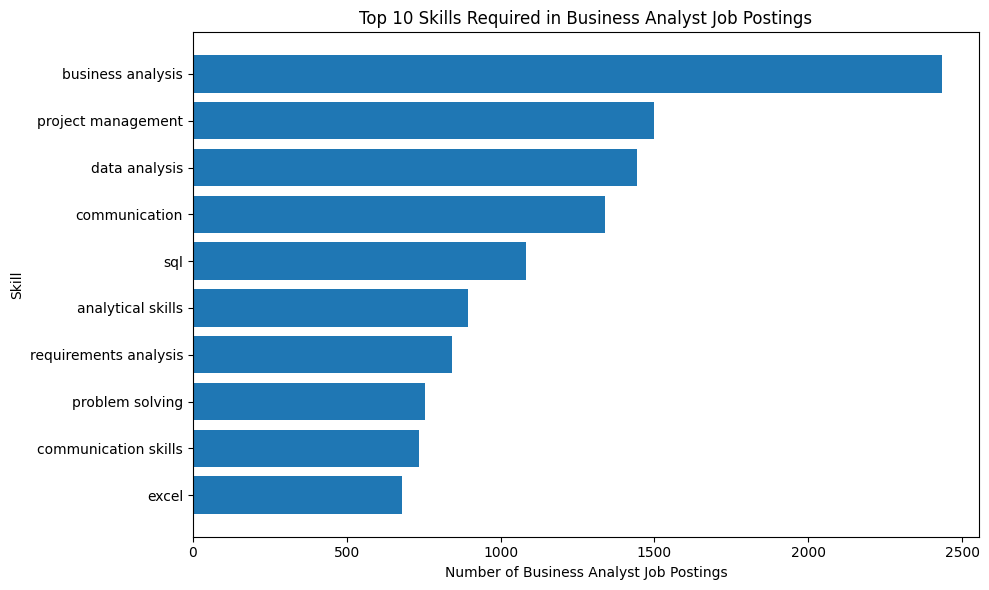

In [ ]:
if len(skill_df) > 0:

    top10 = skill_df.head(10).sort_values(
        "job_count"
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        top10["skill"],
        top10["job_count"]
    )

    plt.xlabel(
        "Number of Business Analyst Job Postings"
    )

    plt.ylabel("Skill")

    plt.title(
        "Top 10 Skills Required in Business Analyst Job Postings"
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "top10_ba_skills.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


16. VISUALISATION 2 - SKILL CATEGORY

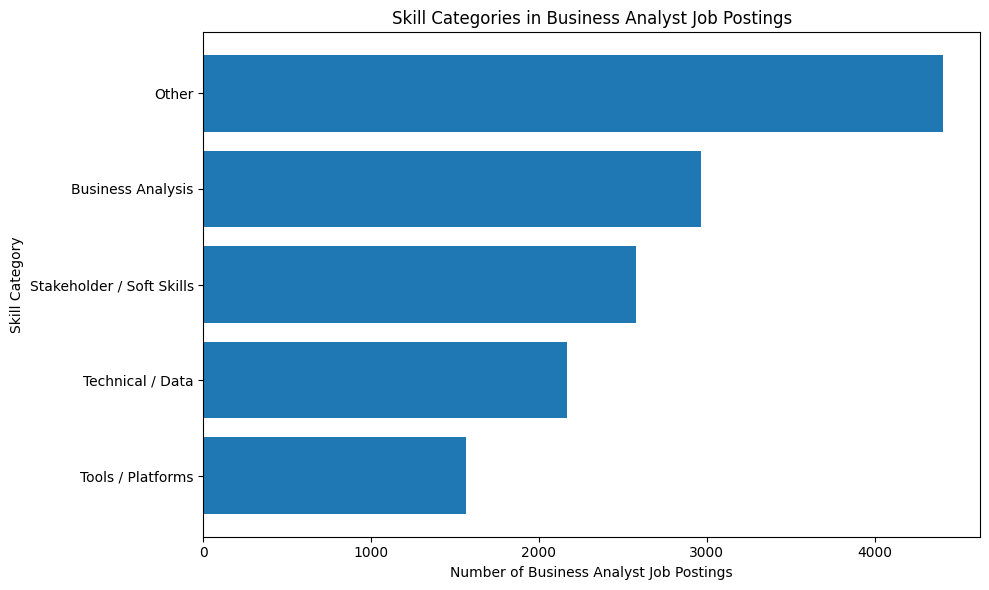

In [ ]:
if "category_df" in locals():

    category_plot = category_df.sort_values(
        "job_count"
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        category_plot["category"],
        category_plot["job_count"]
    )

    plt.xlabel(
        "Number of Business Analyst Job Postings"
    )

    plt.ylabel("Skill Category")

    plt.title(
        "Skill Categories in Business Analyst Job Postings"
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "skill_categories.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

17. VISUALISATION 3 - BA LOCATION

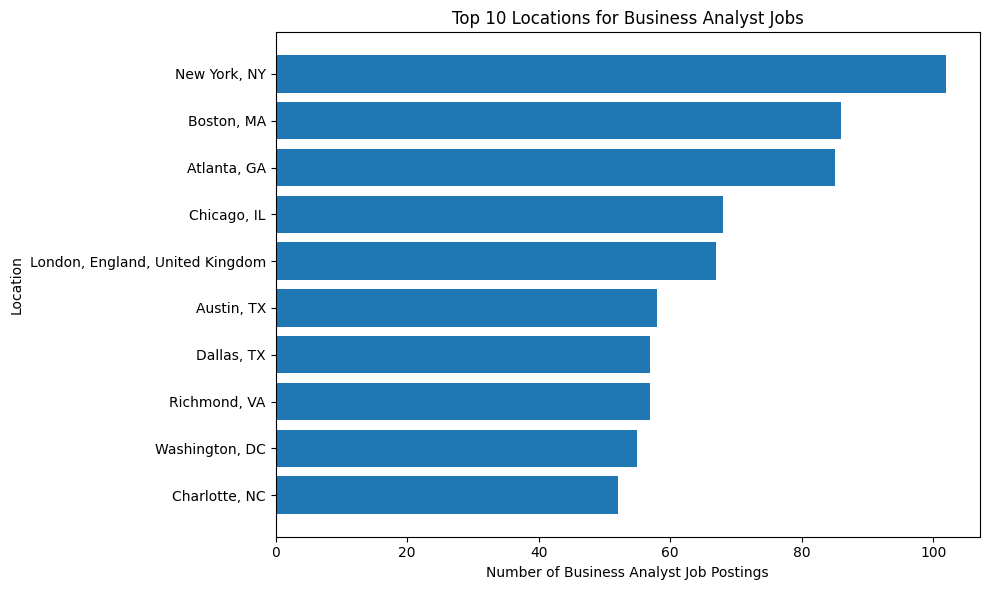

In [ ]:
if "location_df" in locals():

    top_locations = (
        location_df
        .head(10)
        .sort_values("job_count")
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_locations["location"],
        top_locations["job_count"]
    )

    plt.xlabel(
        "Number of Business Analyst Job Postings"
    )

    plt.ylabel("Location")

    plt.title(
        "Top 10 Locations for Business Analyst Jobs"
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "top10_ba_locations.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

18. VISUALISATION 4 - BIVARIATE ANALYSIS: LOCATION VS SKILL CATEGORY

14. BIVARIATE ANALYSIS: LOCATION VS CATEGORY (FIGURE 4)

Bivariate Cross-Tabulation (Location vs Category):
category                         Business Analysis  Other  \
job_location                                                
New York, NY                                    91   1880   
Boston, MA                                      78   1620   
Atlanta, GA                                     88   1707   
Chicago, IL                                     75   1388   
London, England, United Kingdom                 78   1366   

category                         Stakeholder / Soft Skills  Technical / Data  \
job_location                                                                   
New York, NY                                           105                79   
Boston, MA                                              82                99   
Atlanta, GA                                            123                66   
Chicago, IL                                             58      

<Figure size 1000x600 with 0 Axes>

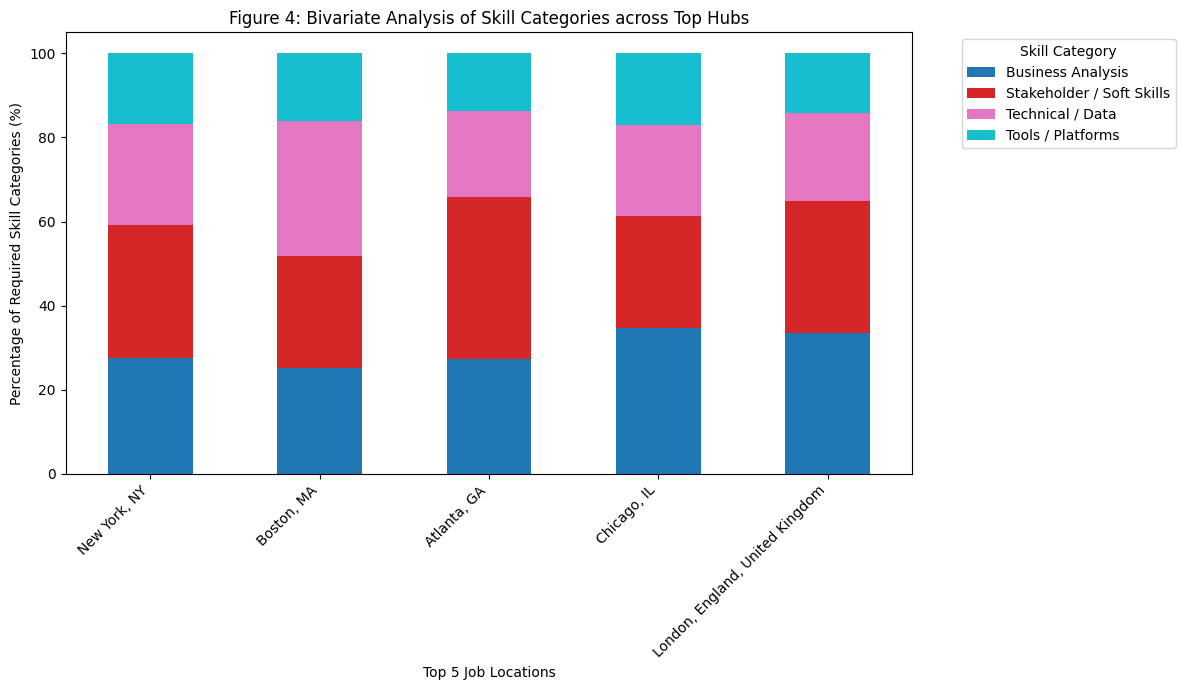

In [ ]:
print("14. BIVARIATE ANALYSIS: LOCATION VS CATEGORY (FIGURE 4)")

if "location_df" in locals() and "skills_long" in locals() and "ba_jobs" in locals():

    top_5_locs = location_df.head(5)["location"].tolist()

    skills_with_loc = skills_long.merge(
        ba_jobs[["job_link", "job_location"]].dropna(subset=["job_location"]),
        on="job_link",
        how="inner"
    )

    skills_with_loc["job_location"] = skills_with_loc["job_location"].astype(str).str.strip()

    bivariate_df = skills_with_loc[skills_with_loc["job_location"].isin(top_5_locs)]

    cross_tab = pd.crosstab(
        bivariate_df["job_location"], 
        bivariate_df["category"]
    )

    cross_tab = cross_tab.reindex(top_5_locs)
    
    print("\nBivariate Cross-Tabulation (Location vs Category):")
    print(cross_tab)

    cross_tab_core = cross_tab.drop(columns=["Other"])
    cross_tab_pct = cross_tab_core.div(cross_tab_core.sum(axis=1), axis=0) * 100

    plt.figure(figsize=(10, 6))
    
    cross_tab_pct.plot(
        kind="bar", 
        stacked=True, 
        colormap="tab10", 
        figsize=(12, 7)
    )

    plt.xlabel("Top 5 Job Locations")
    plt.ylabel("Percentage of Required Skill Categories (%)")
    plt.title("Figure 4: Bivariate Analysis of Skill Categories across Top Hubs")
    
    plt.legend(title="Skill Category", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "figure4_bivariate_location_vs_category.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    
    cross_tab_pct.to_csv(
        OUTPUT_DIR / "bivariate_location_vs_category_pct.csv"
    )

19. FINAL EDA SUMMARY

In [ ]:
print("FINAL EDA SUMMARY")

print("Total LinkedIn postings:", len(merged))
print("BA postings:", len(ba_jobs))

if len(merged) > 0:
    print(
        "BA percentage:",
        round(len(ba_jobs) / len(merged) * 100, 2),
        "%"
    )

if len(skills_long) > 0:

    print(
        "Unique normalized skills:",
        skills_long["skill_normalized"].nunique()
    )

    print(
        "\nTop 10 skills:"
    )

    print(
        skill_df.head(10).to_string(index=False)
    )

print("\nOutput files saved to:")
print(OUTPUT_DIR)